In [45]:
import pandas as pd

file_path = "/Users/krishaanggupta/Desktop/Georgia Tech/Semester 2/Practice of QCF - Capstone/fiserv-capstone/data/processed_data/splits/00_full_dataset.csv"

df = pd.read_csv(file_path)

df.head()

,Period,Geo,Sector Name,Sub-Sector Name,Real Sales Index - SA_normalized,Transactional Index - SA_normalized,Real Sales Index - NSA_normalized,Transactional Index - NSA_normalized,Real Sales MOM % - SA_normalized,Real Sales YOY % - SA_normalized,...,CrudeOilPrices_normalized_YoY_normalized,ImportPriceIndex_normalized_YoY_normalized,Income_normalized_YoY_normalized,JoltsQuitsRate_normalized_YoY_normalized,MonetaryCPI_normalized_YoY_normalized,PersonalConsumptionExpenditures_normalized_YoY_normalized,Unemployment_normalized_YoY_normalized,USNaturalGasCompositePrice_normalized_YoY_normalized,Oil_ImportPrice_interaction,Unemployment_Income_interaction
0,2019-01-01,AK,ALL,ALL,0.259101,0.264438,0.192454,0.162304,-0.055139,0.009152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.254578,0.516182
1,2019-02-01,AK,ALL,ALL,0.254159,0.259978,0.184525,0.158606,-0.234379,0.009152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.870159,0.660978
2,2019-03-01,AK,ALL,ALL,0.257680,0.264121,0.234942,0.197608,0.075009,0.009152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.612665,0.653077
3,2019-04-01,AK,ALL,ALL,0.257422,0.263229,0.235451,0.186326,-0.064273,0.009152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.260662,0.725947
4,2019-05-01,AK,ALL,ALL,0.263010,0.265675,0.292571,0.214637,0.148075,0.009152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.430205,0.798782


In [46]:
# Clean column names (remove hidden spaces)
df.columns = df.columns.str.strip()

# Filter for US, ALL sector, ALL subsector
filtered_df = (
    df[
        (df["Geo"] == "US") &
        (df["Sector Name"] == "ALL") &
        (df["Sub-Sector Name"] == "ALL")
    ]
    .copy()
)

# Convert Period to datetime and sort
filtered_df["Period"] = pd.to_datetime(filtered_df["Period"])
filtered_df = filtered_df.sort_values("Period").reset_index(drop=True)

filtered_df.head()

# Save to CSV
output_path = "/Users/krishaanggupta/Desktop/Georgia Tech/Semester 2/Practice of QCF - Capstone/fiserv-capstone/models/us_all_sector_dataset.csv"
filtered_df.to_csv(output_path, index=False)

print("Saved successfully!")
print("Filtered DataFrame columns:", filtered_df.columns.tolist())

Saved successfully!
Filtered DataFrame columns: ['Period', 'Geo', 'Sector Name', 'Sub-Sector Name', 'Real Sales Index - SA_normalized', 'Transactional Index - SA_normalized', 'Real Sales Index - NSA_normalized', 'Transactional Index - NSA_normalized', 'Real Sales MOM % - SA_normalized', 'Real Sales YOY % - SA_normalized', 'Transaction MOM % - SA_normalized', 'Transaction YOY %  - SA_normalized', 'Real Sales MOM % - NSA_normalized', 'Real Sales YOY % - NSA_normalized', 'Transaction MOM % - NSA_normalized', 'Transaction YOY % - NSA_normalized', 'ConsumerSentimentIndex_normalized', 'CreditSpreadBAA_normalized', 'CreditSpreadGS10_normalized', 'CrudeOilPrices_normalized', 'ImportPriceIndex_normalized', 'Income_normalized', 'JoltsQuitsRate_normalized', 'MonetaryCPI_normalized', 'PersonalConsumptionExpenditures_normalized', 'Unemployment_normalized', 'USNaturalGasCompositePrice_normalized', 'Real Sales Index - SA_normalized_lag1', 'Transactional Index - SA_normalized_lag1', 'Real Sales Index 

In [47]:
# ============================================================
# METRIC HELPERS: Directional Accuracy + MAPE
# ============================================================
def directional_accuracy(y_true, y_pred):
    """
    % of periods where the model correctly predicts whether
    y_true moves UP or DOWN relative to the previous period.
    
    i.e., sign(y_true[t] - y_true[t-1]) == sign(y_pred[t] - y_pred[t-1])
    """
    import numpy as np
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    actual_dir    = np.sign(np.diff(y_true))
    predicted_dir = np.sign(np.diff(y_pred))
    
    # Exclude ties (where diff == 0)
    mask = actual_dir != 0
    if mask.sum() == 0:
        return np.nan
    
    return (actual_dir[mask] == predicted_dir[mask]).mean() * 100.0

def mape(y_true, y_pred, eps=1e-6):
    """Mean Absolute Percentage Error (%). eps guards against near-zero actuals."""
    import numpy as np
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100.0

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# =========================
# FSBI + MACRO PCE FORECASTING EQUATION
# (NOW WITH ALL TRANSACTIONAL VARS CONFIRMED)
# =========================
target = 'PersonalConsumptionExpenditures_normalized'

# ALL confirmed columns from your dataset
X_vars = [
    # FSBI Contemporaneous (20-day lead) - ALL EXIST
    'Real Sales Index - SA_normalized',
    'Transactional Index - SA_normalized',
    'Real Sales MOM % - SA_normalized', 
    'Transaction MOM % - SA_normalized',
    'Real Sales YOY % - SA_normalized',
    'Transaction YOY %  - SA_normalized',
    
    # Core Macros (lag1 for timing discipline)
    'ConsumerSentimentIndex_normalized_lag1',
    'Income_normalized_lag1',
    'Unemployment_normalized_lag1',
    'JoltsQuitsRate_normalized_lag1',
    'MonetaryCPI_normalized_lag1',
    'CrudeOilPrices_normalized_lag1',
    'ImportPriceIndex_normalized_lag1',
    'USNaturalGasCompositePrice_normalized_lag1',
    
    # Credit spreads (lag1)
    'CreditSpreadBAA_normalized_lag1',
    'CreditSpreadGS10_normalized_lag1',
    
    # Interactions
    'Oil_ImportPrice_interaction',
    'Unemployment_Income_interaction',

    # "PersonalConsumptionExpenditures_normalized_lag1",

    # "PersonalConsumptionExpenditures_normalized_MoM_normalized"
]

print(f"✅ Using ALL {len(X_vars)} confirmed columns")

# Prepare data  
data = filtered_df[X_vars + [target]].dropna()
y = data[target]
X = data[X_vars]


✅ Using ALL 18 confirmed columns


In [48]:
print(data.shape)
print(data.info())
print(data.describe().T)

(84, 19)
<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, 1 to 84
Data columns (total 19 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Real Sales Index - SA_normalized            84 non-null     float64
 1   Transactional Index - SA_normalized         84 non-null     float64
 2   Real Sales MOM % - SA_normalized            84 non-null     float64
 3   Transaction MOM % - SA_normalized           84 non-null     float64
 4   Real Sales YOY % - SA_normalized            84 non-null     float64
 5   Transaction YOY %  - SA_normalized          84 non-null     float64
 6   ConsumerSentimentIndex_normalized_lag1      84 non-null     float64
 7   Income_normalized_lag1                      84 non-null     float64
 8   Unemployment_normalized_lag1                84 non-null     float64
 9   JoltsQuitsRate_normalized_lag1              84 non-null     float64
 10  MonetaryCPI_

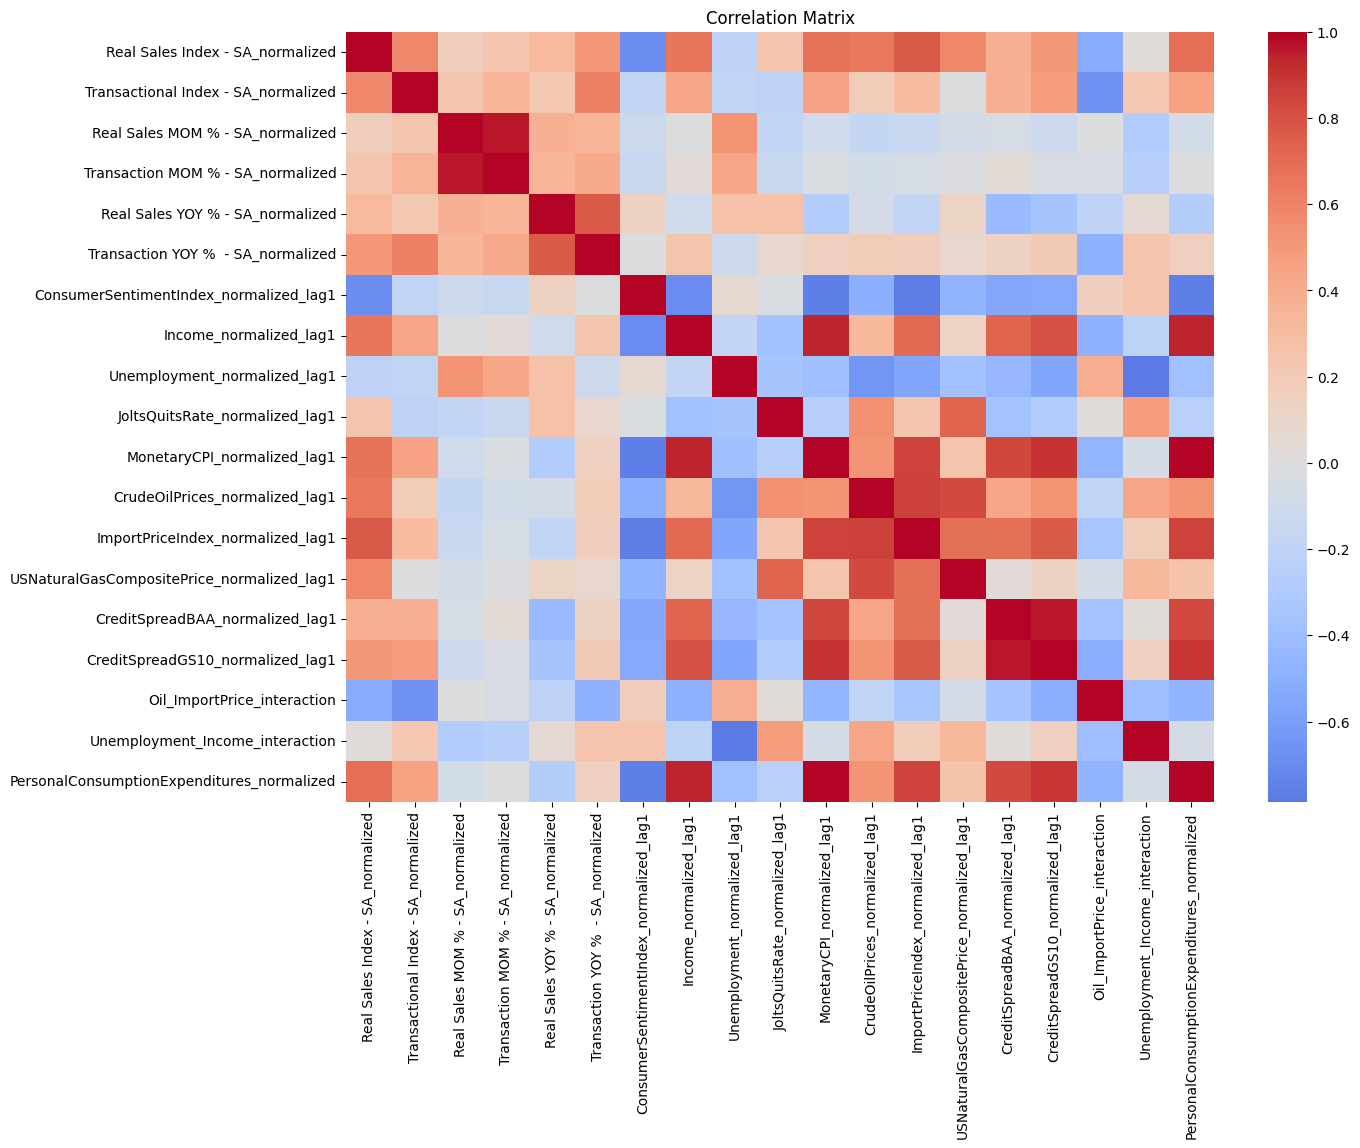

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = data.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

X_for_vif = numeric_df.drop(columns=['PersonalConsumptionExpenditures_normalized'], errors='ignore')
X_for_vif = X_for_vif.dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_for_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_for_vif.values, i)
    for i in range(X_for_vif.shape[1])
]

print(vif_data.sort_values("VIF", ascending=False))

                                       Feature          VIF
0             Real Sales Index - SA_normalized  8353.308141
1          Transactional Index - SA_normalized  5730.929956
4             Real Sales YOY % - SA_normalized   547.147631
15            CreditSpreadGS10_normalized_lag1   224.282665
10                 MonetaryCPI_normalized_lag1   177.981642
12            ImportPriceIndex_normalized_lag1   124.551486
14             CreditSpreadBAA_normalized_lag1   115.859461
7                       Income_normalized_lag1    45.638741
5           Transaction YOY %  - SA_normalized    41.442405
3            Transaction MOM % - SA_normalized    33.660026
2             Real Sales MOM % - SA_normalized    32.454140
11              CrudeOilPrices_normalized_lag1    23.503282
17             Unemployment_Income_interaction    22.935949
9               JoltsQuitsRate_normalized_lag1    20.781067
13  USNaturalGasCompositePrice_normalized_lag1    17.408418
6       ConsumerSentimentIndex_normalize

In [51]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("------------------------")

for col in numeric_df.columns:
    adf_test(numeric_df[col], col)

Real Sales Index - SA_normalized
ADF Statistic: -2.315665102204167
p-value: 0.1669654275564501
------------------------
Transactional Index - SA_normalized
ADF Statistic: -4.956435114178834
p-value: 2.7047800806831875e-05
------------------------
Real Sales MOM % - SA_normalized
ADF Statistic: -9.148912593245266
p-value: 2.7199758695135584e-15
------------------------
Transaction MOM % - SA_normalized
ADF Statistic: -4.870451891738185
p-value: 3.979940795573057e-05
------------------------
Real Sales YOY % - SA_normalized
ADF Statistic: -1.748756113979406
p-value: 0.4061829228190157
------------------------
Transaction YOY %  - SA_normalized
ADF Statistic: -2.3143985917495065
p-value: 0.16736618217227112
------------------------
ConsumerSentimentIndex_normalized_lag1
ADF Statistic: -1.7053567979410627
p-value: 0.42835462836078825
------------------------
Income_normalized_lag1
ADF Statistic: -0.7227131041869935
p-value: 0.8407782919762905
------------------------
Unemployment_normalize

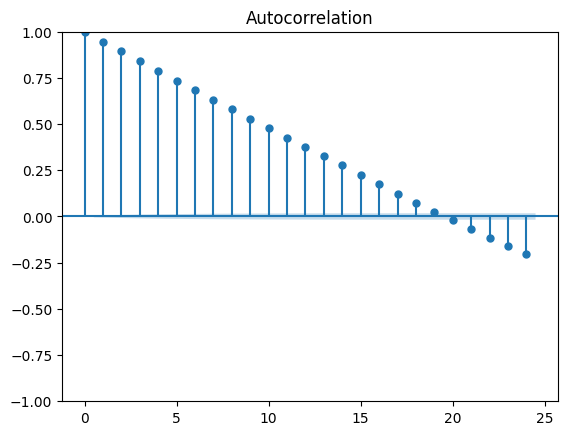

In [52]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['PersonalConsumptionExpenditures_normalized'].dropna(), lags=24)
plt.show()

In [53]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    df['PersonalConsumptionExpenditures_normalized'].dropna(),
    lags=[12],
    return_df=True
)

print(lb_test)

          lb_stat  lb_pvalue
12  889099.525184        0.0


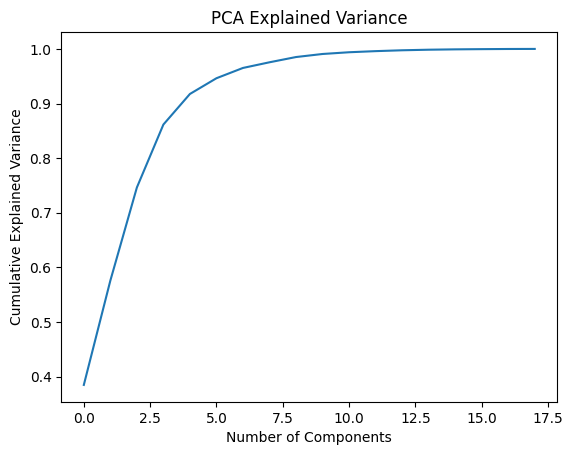

[3.84651472e-01 1.91033261e-01 1.70514860e-01 1.15314592e-01
 5.59938197e-02 2.88077402e-02 1.88402554e-02 1.03757703e-02
 9.60483026e-03 5.59334316e-03 3.17452414e-03 2.03508513e-03
 1.57866372e-03 1.03824302e-03 6.44446202e-04 3.89269478e-04
 2.91129711e-04 1.18695312e-04]


In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = numeric_df.drop(columns=['PersonalConsumptionExpenditures_normalized'], errors='ignore')
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

print(explained_variance)

In [55]:
data["PCE_MOM"] = data["PersonalConsumptionExpenditures_normalized"].diff()
data["PCE_MOM_lag1"] = data["PCE_MOM"].shift(1)
data["PCE_MOM_lag2"] = data["PCE_MOM"].shift(2)
data["PCE_MOM_lag3"] = data["PCE_MOM"].shift(3)

target = "PCE_MOM"

In [56]:
# ------------------------------
# MAKE X VARIABLES STATIONARY
# ------------------------------

# 1. Create first differences for level-type macro variables
level_vars = [
    "ConsumerSentimentIndex_normalized_lag1",
    "Income_normalized_lag1",
    "Unemployment_normalized_lag1",
    "JoltsQuitsRate_normalized_lag1",
    "MonetaryCPI_normalized_lag1",
    "CrudeOilPrices_normalized_lag1",
    "ImportPriceIndex_normalized_lag1",
    "USNaturalGasCompositePrice_normalized_lag1",
    "CreditSpreadBAA_normalized_lag1",
    "CreditSpreadGS10_normalized_lag1"
]

for var in level_vars:
    data[var + "_diff"] = data[var].diff()

# 2. Keep already stationary momentum variables
momentum_vars = [
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized",
    "PCE_MOM_lag1",
    "PCE_MOM_lag2",
    "PCE_MOM_lag3"
]

# 3. Final stationary X list (clean + defensible)
X_vars = (
    momentum_vars
    + [var + "_diff" for var in level_vars]
)


# # 4. Drop NA after differencing
model_df = data[X_vars + [target]].dropna().copy()

print("Final dataset shape:", model_df.shape)
print("Number of predictors:", len(X_vars))

model_df.head()

Final dataset shape: (80, 16)
Number of predictors: 15


,Real Sales MOM % - SA_normalized,Transaction MOM % - SA_normalized,PCE_MOM_lag1,PCE_MOM_lag2,PCE_MOM_lag3,ConsumerSentimentIndex_normalized_lag1_diff,Income_normalized_lag1_diff,Unemployment_normalized_lag1_diff,JoltsQuitsRate_normalized_lag1_diff,MonetaryCPI_normalized_lag1_diff,CrudeOilPrices_normalized_lag1_diff,ImportPriceIndex_normalized_lag1_diff,USNaturalGasCompositePrice_normalized_lag1_diff,CreditSpreadBAA_normalized_lag1_diff,CreditSpreadGS10_normalized_lag1_diff,PCE_MOM
5,-0.033448,-0.013116,0.008544,0.033149,0.026542,0.199930,0.004283,-0.049706,0.00000,0.002497,-0.170285,0.024428,-0.216253,-0.064602,-0.097392,0.005582
6,0.046468,-0.017735,0.005582,0.008544,0.033149,-0.128526,0.016526,0.000000,0.00000,-0.003290,-0.346078,-0.170999,-0.500086,-0.156890,-0.247226,0.015720
7,0.072726,0.030767,0.015720,0.005582,0.008544,0.014281,0.017867,0.049706,0.31022,0.023346,0.151494,0.000000,0.054063,-0.166119,-0.007492,0.005468
8,-0.125922,-0.070856,0.005468,0.015720,0.005582,-0.614069,0.040407,-0.049706,-0.31022,0.009275,-0.143169,-0.085499,-0.063074,-0.378381,-0.322143,0.007177
9,0.024776,-0.000028,0.007177,0.005468,0.015720,0.242772,0.019165,-0.049706,0.00000,0.015617,0.120108,0.012214,0.252296,0.036915,0.052442,0.020960


In [57]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Last 3 observations for OOS
train_df = model_df.iloc[:-3]
test_df  = model_df.iloc[-3:]

X_train = train_df[X_vars]
y_train = train_df[target]

X_test = test_df[X_vars]
y_test = test_df[target]

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_const).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":3}
)

print(model.summary())

y_pred = model.predict(X_test_const)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

da_val   = directional_accuracy(y_test, y_pred)
mape_val = mape(y_test, y_pred)

print("3-Month OOS RMSE:", rmse)
print("3-Month OOS R2:", r2)
print("*** 3-Month OOS Directional Accuracy: {:.1f}%".format(da_val))
print("*** 3-Month OOS MAPE                : {:.2f}%".format(mape_val))

                            OLS Regression Results                            
Dep. Variable:                PCE_MOM   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     9.782
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.35e-11
Time:                        20:52:35   Log-Likelihood:                 191.54
No. Observations:                  77   AIC:                            -351.1
Df Residuals:                      61   BIC:                            -313.6
Df Model:                          15                                         
Covariance Type:                  HAC                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

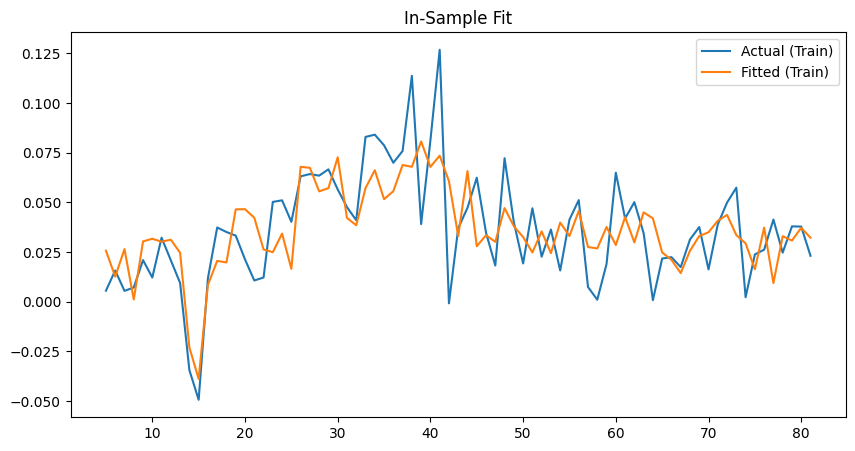

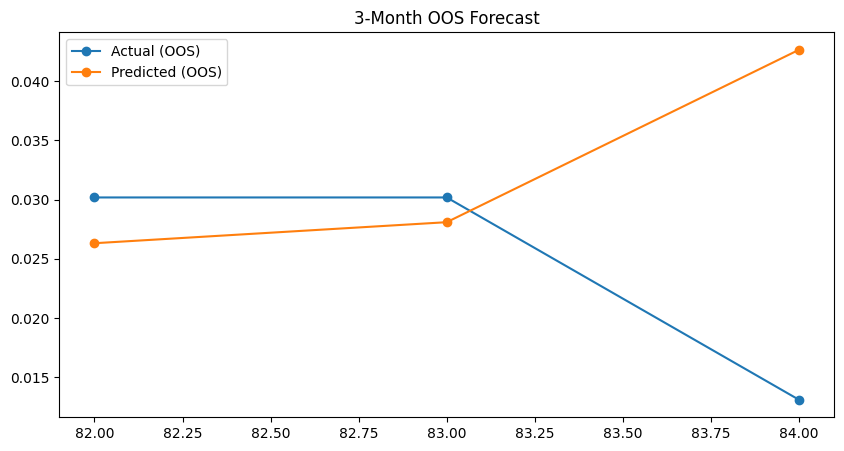

In [58]:
import matplotlib.pyplot as plt

# In-sample fitted
fitted = model.predict(X_train_const)

plt.figure(figsize=(10,5))
plt.plot(y_train.index, y_train, label="Actual (Train)")
plt.plot(y_train.index, fitted, label="Fitted (Train)")
plt.legend()
plt.title("In-Sample Fit")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, marker='o', label="Actual (OOS)")
plt.plot(y_test.index, y_pred, marker='o', label="Predicted (OOS)")
plt.legend()
plt.title("3-Month OOS Forecast")
plt.show()

In [59]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model.resid
lb_test = acorr_ljungbox(residuals, lags=[3], return_df=True)
print(lb_test)

    lb_stat  lb_pvalue
3  1.708349   0.635079


In [60]:
from scipy.stats import jarque_bera

jb_stat, jb_p = jarque_bera(residuals)
print("JB p-value:", jb_p)

JB p-value: 0.645999587368831


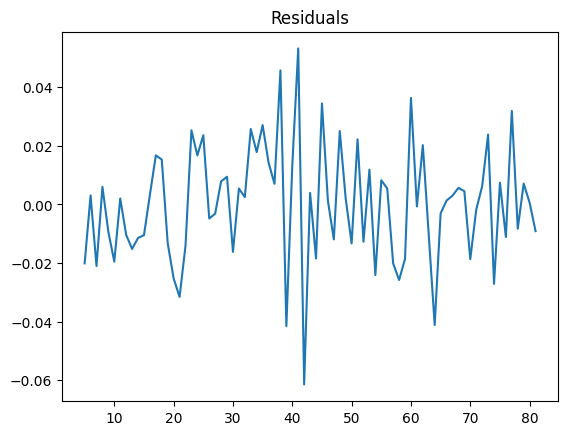

In [61]:
plt.plot(residuals)
plt.title("Residuals")
plt.show()

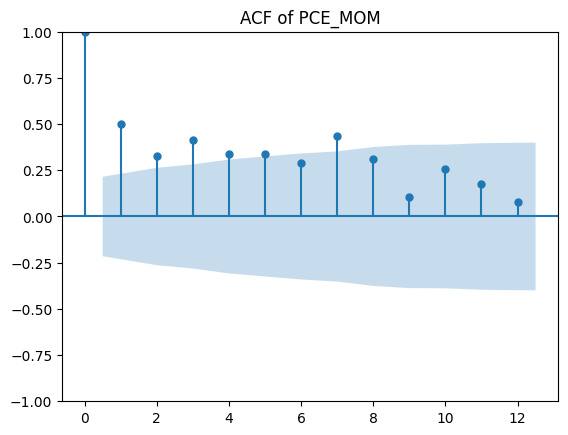

In [62]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(data["PCE_MOM"].dropna(), lags=12)
plt.title("ACF of PCE_MOM")
plt.show()

In [63]:
# Create AR lags
for i in range(1, 5):
    data[f"PCE_MOM_lag{i}"] = data["PCE_MOM"].shift(i)

In [64]:
# FSBI variables
fsbi_vars = [
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized"
]

# AR variables
ar_vars = [
    "PCE_MOM_lag1",
    "PCE_MOM_lag2",
    "PCE_MOM_lag3",
    "PCE_MOM_lag4"
]

# Final X list
X_vars = ar_vars + fsbi_vars

target = "PCE_MOM"

In [65]:
model_df = data[X_vars + [target]].dropna().copy()

print("Final dataset shape:", model_df.shape)

Final dataset shape: (79, 7)


In [66]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Last 3 observations OOS
train_df = model_df.iloc[:-3]
test_df  = model_df.iloc[-3:]

X_train = train_df[X_vars]
y_train = train_df[target]

X_test = test_df[X_vars]
y_test = test_df[target]

# Add constant
X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

# Estimate model
model = sm.OLS(y_train, X_train_const).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3}
)

print(model.summary())

# Forecast
y_pred = model.predict(X_test_const)

# OOS metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

da_val   = directional_accuracy(y_test, y_pred)
mape_val = mape(y_test, y_pred)

print("AR + FSBI 3-Month OOS RMSE:", rmse)
print("AR + FSBI 3-Month OOS R2:", r2)
print("*** AR + FSBI OOS Directional Accuracy: {:.1f}%".format(da_val))
print("*** AR + FSBI OOS MAPE                : {:.2f}%".format(mape_val))

                            OLS Regression Results                            
Dep. Variable:                PCE_MOM   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     6.580
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.57e-05
Time:                        20:52:35   Log-Likelihood:                 182.44
No. Observations:                  76   AIC:                            -350.9
Df Residuals:                      69   BIC:                            -334.6
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

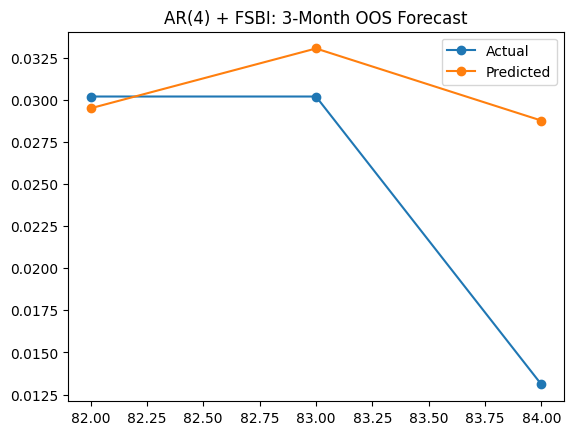

In [67]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.index, y_test, marker="o", label="Actual")
plt.plot(y_test.index, y_pred, marker="o", label="Predicted")
plt.title("AR(4) + FSBI: 3-Month OOS Forecast")
plt.legend()
plt.show()

In [68]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import numpy as np

# -----------------------------
# 1. Create AR lags
# -----------------------------
for i in range(1, 4):
    data[f"PCE_MOM_lag{i}"] = data["PCE_MOM"].shift(i)

# -----------------------------
# 2. Create FSBI lags (Richmond-style)
# -----------------------------
data["RealSales_MOM_lag1"] = data["Real Sales MOM % - SA_normalized"].shift(1)
data["Transaction_MOM_lag1"] = data["Transaction MOM % - SA_normalized"].shift(1)

# -----------------------------
# 3. Define variables
# -----------------------------
target = "PCE_MOM"

ar_vars = [
    "PCE_MOM_lag1",
    "PCE_MOM_lag2",
    "PCE_MOM_lag3"
]

fsbi_vars = [
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized",
    "RealSales_MOM_lag1",
    "Transaction_MOM_lag1"
]

# Build dataset
model_df = data[ar_vars + fsbi_vars + [target]].dropna().copy()

# -----------------------------
# 4. 3-Month OOS Split
# -----------------------------
train_df = model_df.iloc[:-5]
test_df  = model_df.iloc[-5:]

y_train = train_df[target]
y_test  = test_df[target]

# -----------------------------
# MODEL A: AR(3)
# -----------------------------
X_train_A = sm.add_constant(train_df[ar_vars])
X_test_A  = sm.add_constant(test_df[ar_vars])

model_A = sm.OLS(y_train, X_train_A).fit(cov_type="HAC", cov_kwds={"maxlags":3})
y_pred_A = model_A.predict(X_test_A)

rmse_A = np.sqrt(mean_squared_error(y_test, y_pred_A))

# -----------------------------
# MODEL B: AR(3) + FSBI
# -----------------------------
X_train_B = sm.add_constant(train_df[ar_vars + fsbi_vars])
X_test_B  = sm.add_constant(test_df[ar_vars + fsbi_vars])

model_B = sm.OLS(y_train, X_train_B).fit(cov_type="HAC", cov_kwds={"maxlags":3})
y_pred_B = model_B.predict(X_test_B)

rmse_B = np.sqrt(mean_squared_error(y_test, y_pred_B))

# -----------------------------
# 5. Compare Results
# -----------------------------
da_A   = directional_accuracy(y_test, y_pred_A)
da_B   = directional_accuracy(y_test, y_pred_B)
mape_A = mape(y_test, y_pred_A)
mape_B = mape(y_test, y_pred_B)

print("AR(3) OOS RMSE:", rmse_A)
print("AR(3) + FSBI OOS RMSE:", rmse_B)
print("RMSE Improvement (positive = FSBI helps):", rmse_A - rmse_B)
print()
print("*** AR(3) Directional Accuracy     : {:.1f}%".format(da_A))
print("*** AR(3)+FSBI Directional Accuracy: {:.1f}%".format(da_B))
print("*** AR(3) MAPE     : {:.2f}%".format(mape_A))
print("*** AR(3)+FSBI MAPE: {:.2f}%".format(mape_B))

print("\n--- AR(3) Model Summary ---")
print(model_A.summary())

print("\n--- AR(3) + FSBI Model Summary ---")
print(model_B.summary())

AR(3) OOS RMSE: 0.009370396256921069
AR(3) + FSBI OOS RMSE: 0.00858254038624368
RMSE Improvement (positive = FSBI helps): 0.0007878558706773883

*** AR(3) Directional Accuracy     : 66.7%
*** AR(3)+FSBI Directional Accuracy: 66.7%
*** AR(3) MAPE     : 40.25%
*** AR(3)+FSBI MAPE: 35.84%

--- AR(3) Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                PCE_MOM   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     9.240
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.08e-05
Time:                        20:52:35   Log-Likelihood:                 174.52
No. Observations:                  75   AIC:                            -341.0
Df Residuals:                      71   BIC:                            -331.8
Df Model:                           3               

In [69]:
print(train_df.columns)

Index(['PCE_MOM_lag1', 'PCE_MOM_lag2', 'PCE_MOM_lag3',
       'Real Sales MOM % - SA_normalized', 'Transaction MOM % - SA_normalized',
       'RealSales_MOM_lag1', 'Transaction_MOM_lag1', 'PCE_MOM'],
      dtype='object')


In [70]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import numpy as np

# -----------------------------
# 1. Create AR lags
# -----------------------------
for i in range(1, 4):
    data[f"PCE_MOM_lag{i}"] = data["PCE_MOM"].shift(i)

# -----------------------------
# 2. Create FSBI lags (Richmond-style)
# -----------------------------
data["RealSales_MOM_lag1"] = data["Real Sales MOM % - SA_normalized"].shift(1)
data["Transaction_MOM_lag1"] = data["Transaction MOM % - SA_normalized"].shift(1)

# -----------------------------
# 3. Define variables
# -----------------------------
target = "PCE_MOM"

ar_vars = [
    "PCE_MOM_lag1",
    "PCE_MOM_lag2",
    "PCE_MOM_lag3"
]

fsbi_vars = [
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized",
    "RealSales_MOM_lag1",
    "Transaction_MOM_lag1",

    "ConsumerSentimentIndex_normalized_lag1",
    "Income_normalized_lag1",
    "Unemployment_normalized_lag1",
    "JoltsQuitsRate_normalized_lag1",
    "MonetaryCPI_normalized_lag1",
    "CrudeOilPrices_normalized_lag1",
    "ImportPriceIndex_normalized_lag1",
    "USNaturalGasCompositePrice_normalized_lag1",
    "CreditSpreadBAA_normalized_lag1",
    "CreditSpreadGS10_normalized_lag1"
]

# Build dataset
model_df = data[ar_vars + fsbi_vars + [target]].dropna().copy()

# -----------------------------
# 4. 3-Month OOS Split
# -----------------------------
train_df = model_df.iloc[:-5]
test_df  = model_df.iloc[-5:]

y_train = train_df[target]
y_test  = test_df[target]

# -----------------------------
# MODEL A: AR(3)
# -----------------------------
X_train_A = sm.add_constant(train_df[ar_vars])
X_test_A  = sm.add_constant(test_df[ar_vars])

model_A = sm.OLS(y_train, X_train_A).fit(cov_type="HAC", cov_kwds={"maxlags":3})
y_pred_A = model_A.predict(X_test_A)

rmse_A = np.sqrt(mean_squared_error(y_test, y_pred_A))

# -----------------------------
# MODEL B: AR(3) + FSBI
# -----------------------------
X_train_B = sm.add_constant(train_df[ar_vars + fsbi_vars])
X_test_B  = sm.add_constant(test_df[ar_vars + fsbi_vars])

model_B = sm.OLS(y_train, X_train_B).fit(cov_type="HAC", cov_kwds={"maxlags":3})
y_pred_B = model_B.predict(X_test_B)

rmse_B = np.sqrt(mean_squared_error(y_test, y_pred_B))

# -----------------------------
# 5. Compare Results
# -----------------------------
da_A   = directional_accuracy(y_test, y_pred_A)
da_B   = directional_accuracy(y_test, y_pred_B)
mape_A = mape(y_test, y_pred_A)
mape_B = mape(y_test, y_pred_B)

print("AR(3) OOS RMSE:", rmse_A)
print("AR(3) + FSBI OOS RMSE:", rmse_B)
print("RMSE Improvement (positive = FSBI helps):", rmse_A - rmse_B)
print()
print("*** AR(3) Directional Accuracy           : {:.1f}%".format(da_A))
print("*** AR(3)+FSBI+Macro Directional Accuracy: {:.1f}%".format(da_B))
print("*** AR(3) MAPE           : {:.2f}%".format(mape_A))
print("*** AR(3)+FSBI+Macro MAPE: {:.2f}%".format(mape_B))

print("\n--- AR(3) Model Summary ---")
print(model_A.summary())

print("\n--- AR(3) + FSBI Model Summary ---")
print(model_B.summary())

AR(3) OOS RMSE: 0.009370396256921069
AR(3) + FSBI OOS RMSE: 0.014878701059517522
RMSE Improvement (positive = FSBI helps): -0.005508304802596453

*** AR(3) Directional Accuracy           : 66.7%
*** AR(3)+FSBI+Macro Directional Accuracy: 0.0%
*** AR(3) MAPE           : 40.25%
*** AR(3)+FSBI+Macro MAPE: 60.11%

--- AR(3) Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                PCE_MOM   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     9.240
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.08e-05
Time:                        20:52:35   Log-Likelihood:                 174.52
No. Observations:                  75   AIC:                            -341.0
Df Residuals:                      71   BIC:                            -331.8
Df Model:                   

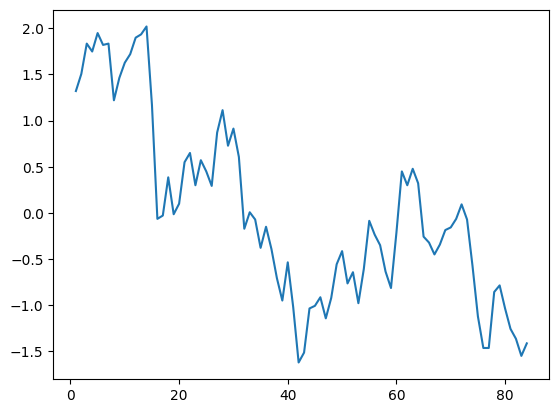

In [71]:
plt.plot(data["ConsumerSentimentIndex_normalized_lag1"])

In [72]:
import itertools
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# ===============================
# FIXED BLOCKS
# ===============================
target = "PCE_MOM"

ar_vars = [
    "PCE_MOM_lag1",
    "PCE_MOM_lag2",
    "PCE_MOM_lag3"
]

fsbi_vars = [
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized",
    "RealSales_MOM_lag1",
    "Transaction_MOM_lag1"
]

macro_candidates = [
    "ConsumerSentimentIndex_normalized_lag1",
    "Income_normalized_lag1",
    "Unemployment_normalized_lag1",
    "JoltsQuitsRate_normalized_lag1",
    "MonetaryCPI_normalized_lag1",
    "CrudeOilPrices_normalized_lag1",
    "ImportPriceIndex_normalized_lag1",
    "USNaturalGasCompositePrice_normalized_lag1",
    "CreditSpreadBAA_normalized_lag1",
    "CreditSpreadGS10_normalized_lag1"
]

# ===============================
# BUILD BASE DATASET
# ===============================
base_df = data[ar_vars + fsbi_vars + macro_candidates + [target]].dropna()

train_df = base_df.iloc[:-3]
test_df  = base_df.iloc[-3:]

y_train = train_df[target]
y_test  = test_df[target]

results = []

# ===============================
# SEARCH OVER MACRO COMBINATIONS
# ===============================
for k in range(1, len(macro_candidates)+1):

    for combo in itertools.combinations(macro_candidates, k):

        vars_used = ar_vars + fsbi_vars + list(combo)

        try:
            X_train = sm.add_constant(train_df[vars_used])
            X_test  = sm.add_constant(test_df[vars_used])

            model = sm.OLS(y_train, X_train).fit(
                cov_type="HAC",
                cov_kwds={"maxlags":3}
            )

            y_pred = model.predict(X_test)

            rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
            da_val   = directional_accuracy(y_test, y_pred)
            mape_val = mape(y_test, y_pred)

            results.append({
                "rmse": rmse,
                "da_pct": da_val,
                "mape_pct": mape_val,
                "n_macros": k,
                "macros": combo
            })

        except:
            continue

# ===============================
# RESULTS TABLE
# ===============================
results_df = pd.DataFrame(results).sort_values("rmse")

print("\n🏆 TOP 10 MACRO COMBINATIONS:")
display(results_df.head(10))

for i, row in results_df.head(10).iterrows():
    print(f"\nRMSE: {row['rmse']:.6f}")
    print(f"# Macros: {row['n_macros']}")
    print("Macros:")
    for m in row['macros']:
        print("   -", m)


🏆 TOP 10 MACRO COMBINATIONS:


,rmse,da_pct,mape_pct,n_macros,macros
345,0.006382,100.0,32.743695,4,"(Unemployment_normalized_lag1, CrudeOilPrices_..."
170,0.006798,100.0,34.577060,3,"(CrudeOilPrices_normalized_lag1, CreditSpreadB..."
111,0.007098,100.0,33.485731,3,"(Income_normalized_lag1, CrudeOilPrices_normal..."
310,0.007220,100.0,33.372688,4,"(Income_normalized_lag1, CrudeOilPrices_normal..."
47,0.007353,100.0,36.169615,2,"(CrudeOilPrices_normalized_lag1, CreditSpreadB..."
132,0.007364,100.0,36.126497,3,"(Unemployment_normalized_lag1, CrudeOilPrices_..."
541,0.007456,100.0,34.298363,5,"(Income_normalized_lag1, Unemployment_normaliz..."
32,0.007501,100.0,38.404797,2,"(Unemployment_normalized_lag1, CreditSpreadBAA..."
8,0.007567,100.0,38.541706,1,"(CreditSpreadBAA_normalized_lag1,)"
272,0.007618,100.0,34.879047,4,"(Income_normalized_lag1, Unemployment_normaliz..."



RMSE: 0.006382
# Macros: 4
Macros:
   - Unemployment_normalized_lag1
   - CrudeOilPrices_normalized_lag1
   - CreditSpreadBAA_normalized_lag1
   - CreditSpreadGS10_normalized_lag1

RMSE: 0.006798
# Macros: 3
Macros:
   - CrudeOilPrices_normalized_lag1
   - CreditSpreadBAA_normalized_lag1
   - CreditSpreadGS10_normalized_lag1

RMSE: 0.007098
# Macros: 3
Macros:
   - Income_normalized_lag1
   - CrudeOilPrices_normalized_lag1
   - CreditSpreadBAA_normalized_lag1

RMSE: 0.007220
# Macros: 4
Macros:
   - Income_normalized_lag1
   - CrudeOilPrices_normalized_lag1
   - CreditSpreadBAA_normalized_lag1
   - CreditSpreadGS10_normalized_lag1

RMSE: 0.007353
# Macros: 2
Macros:
   - CrudeOilPrices_normalized_lag1
   - CreditSpreadBAA_normalized_lag1

RMSE: 0.007364
# Macros: 3
Macros:
   - Unemployment_normalized_lag1
   - CrudeOilPrices_normalized_lag1
   - CreditSpreadBAA_normalized_lag1

RMSE: 0.007456
# Macros: 5
Macros:
   - Income_normalized_lag1
   - Unemployment_normalized_lag1
   - Crude

In [73]:
# =====================================================
# MODEL HORSE RACE: OLS vs RIDGE vs LASSO vs FACTOR
# =====================================================

import statsmodels.api as sm
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# -----------------------------
# SETTINGS
# -----------------------------
target = "PCE_MOM"
oos = 3   # your current OOS window

# AR block (fixed)
ar_vars = [
    "PCE_MOM_lag1",
    "PCE_MOM_lag2",
    "PCE_MOM_lag3"
]

# FSBI block (fixed)
fsbi_vars = [
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized",
    "RealSales_MOM_lag1",
    "Transaction_MOM_lag1"
]

# BEST macros from search
best_macros = [
    "Unemployment_normalized_lag1",
    "CrudeOilPrices_normalized_lag1",
    "CreditSpreadBAA_normalized_lag1",
    "CreditSpreadGS10_normalized_lag1"
]

vars_used = ar_vars + fsbi_vars + best_macros

# -----------------------------
# DATA
# -----------------------------
model_df = data[vars_used + [target]].dropna()

train_df = model_df.iloc[:-oos]
test_df  = model_df.iloc[-oos:]

X_train = train_df[vars_used]
X_test  = test_df[vars_used]
y_train = train_df[target]
y_test  = test_df[target]

# -----------------------------
# 1️⃣ OLS
# -----------------------------
X_train_ols = sm.add_constant(X_train)
X_test_ols  = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_ols).fit(
    cov_type="HAC", cov_kwds={"maxlags":3}
)

ols_pred = ols_model.predict(X_test_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, ols_pred))

# -----------------------------
# SCALE DATA (for ML models)
# -----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# -----------------------------
# 2️⃣ RIDGE
# -----------------------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

ridge_pred = ridge.predict(X_test_s)
rmse_ridge = np.sqrt(mean_squared_error(y_test, ridge_pred))

# -----------------------------
# 3️⃣ LASSO
# -----------------------------
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_s, y_train)

lasso_pred = lasso.predict(X_test_s)
rmse_lasso = np.sqrt(mean_squared_error(y_test, lasso_pred))

# -----------------------------
# 4️⃣ PCA FACTOR MODEL
# -----------------------------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca  = pca.transform(X_test_s)

X_train_pca = sm.add_constant(X_train_pca)
X_test_pca  = sm.add_constant(X_test_pca)

factor_model = sm.OLS(y_train, X_train_pca).fit()
factor_pred = factor_model.predict(X_test_pca)

rmse_factor = np.sqrt(mean_squared_error(y_test, factor_pred))

# -----------------------------
# RESULTS
# -----------------------------
da_ols    = directional_accuracy(y_test, ols_pred)
da_ridge  = directional_accuracy(y_test, ridge_pred)
da_lasso  = directional_accuracy(y_test, lasso_pred)
da_factor = directional_accuracy(y_test, factor_pred)

mape_ols    = mape(y_test, ols_pred)
mape_ridge  = mape(y_test, ridge_pred)
mape_lasso  = mape(y_test, lasso_pred)
mape_factor = mape(y_test, factor_pred)

results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "Factor (PCA)"],
    "OOS_RMSE": [rmse_ols, rmse_ridge, rmse_lasso, rmse_factor],
    "DA_%": [da_ols, da_ridge, da_lasso, da_factor],
    "MAPE_%": [mape_ols, mape_ridge, mape_lasso, mape_factor]
}).sort_values("OOS_RMSE")

print("\n🏁 MODEL COMPARISON (LOWER RMSE = BETTER)\n")
print(results.to_string(index=False))


🏁 MODEL COMPARISON (LOWER RMSE = BETTER)

       Model  OOS_RMSE  DA_%    MAPE_%
       Ridge  0.006310 100.0 32.600571
         OLS  0.006382 100.0 32.743695
       Lasso  0.013240 100.0 66.054047
Factor (PCA)  0.014632   0.0 74.195213


In [74]:
# =====================================================
# RANDOM FOREST FORECAST (TIME-SERIES SAFE)
# =====================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# -----------------------------
# DATA (same vars as best model)
# -----------------------------
target = "PCE_MOM"
oos = 3

vars_used = ar_vars + fsbi_vars + best_macros

model_df = data[vars_used + [target]].dropna()

train_df = model_df.iloc[:-oos]
test_df  = model_df.iloc[-oos:]

X_train = train_df[vars_used]
X_test  = test_df[vars_used]
y_train = train_df[target]
y_test  = test_df[target]

# -----------------------------
# RANDOM FOREST
# (conservative settings)
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,          # VERY IMPORTANT (avoid overfit)
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

da_rf   = directional_accuracy(y_test, rf_pred)
mape_rf = mape(y_test, rf_pred)

print("\n🌲 RANDOM FOREST RMSE:", rmse_rf)
print("*** Random Forest Directional Accuracy: {:.1f}%".format(da_rf))
print("*** Random Forest MAPE                : {:.2f}%".format(mape_rf))


🌲 RANDOM FOREST RMSE: 0.011571155585821821
*** Random Forest Directional Accuracy: 0.0%
*** Random Forest MAPE                : 56.08%


In [75]:
from sklearn.linear_model import ElasticNet

enet = ElasticNet(alpha=0.01, l1_ratio=0.5)
enet.fit(X_train_s, y_train)

enet_pred = enet.predict(X_test_s)

rmse_enet = np.sqrt(mean_squared_error(y_test, enet_pred))
da_enet   = directional_accuracy(y_test, enet_pred)
mape_enet = mape(y_test, enet_pred)

print("Elastic Net RMSE:", rmse_enet)
print("*** Elastic Net Directional Accuracy: {:.1f}%".format(da_enet))
print("*** Elastic Net MAPE                : {:.2f}%".format(mape_enet))

Elastic Net RMSE: 0.011294152176823778
*** Elastic Net Directional Accuracy: 100.0%
*** Elastic Net MAPE                : 55.42%


In [76]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, gbr_pred))
da_gbr   = directional_accuracy(y_test, gbr_pred)
mape_gbr = mape(y_test, gbr_pred)

print("Gradient Boosting RMSE:", rmse_gbr)
print("*** Gradient Boosting Directional Accuracy: {:.1f}%".format(da_gbr))
print("*** Gradient Boosting MAPE                : {:.2f}%".format(mape_gbr))

Gradient Boosting RMSE: 0.010743156127967179
*** Gradient Boosting Directional Accuracy: 0.0%
*** Gradient Boosting MAPE                : 52.46%


In [77]:
from sklearn.linear_model import BayesianRidge

bayes = BayesianRidge()
bayes.fit(X_train_s, y_train)

bayes_pred = bayes.predict(X_test_s)

rmse_bayes = np.sqrt(mean_squared_error(y_test, bayes_pred))
da_bayes   = directional_accuracy(y_test, bayes_pred)
mape_bayes = mape(y_test, bayes_pred)

print("Bayesian Ridge RMSE:", rmse_bayes)
print("*** Bayesian Ridge Directional Accuracy: {:.1f}%".format(da_bayes))
print("*** Bayesian Ridge MAPE                : {:.2f}%".format(mape_bayes))

Bayesian Ridge RMSE: 0.006387119832423233
*** Bayesian Ridge Directional Accuracy: 100.0%
*** Bayesian Ridge MAPE                : 32.69%


In [78]:
comparison = pd.DataFrame({
    "Model": [
        "OLS",
        "Ridge",
        "ElasticNet",
        "Bayesian Ridge",
        "Gradient Boosting",
        "Random Forest"
    ],
    "RMSE": [
        rmse_ols,
        rmse_ridge,
        rmse_enet,
        rmse_bayes,
        rmse_gbr,
        rmse_rf
    ],
    "DA_%": [
        da_ols,
        da_ridge,
        da_enet,
        da_bayes,
        da_gbr,
        da_rf
    ],
    "MAPE_%": [
        mape_ols,
        mape_ridge,
        mape_enet,
        mape_bayes,
        mape_gbr,
        mape_rf
    ]
}).sort_values("RMSE")

print("\n🏆 FINAL MODEL RANKING")
print(comparison)


🏆 FINAL MODEL RANKING
               Model      RMSE   DA_%     MAPE_%
1              Ridge  0.006310  100.0  32.600571
0                OLS  0.006382  100.0  32.743695
3     Bayesian Ridge  0.006387  100.0  32.694662
4  Gradient Boosting  0.010743    0.0  52.463448
2         ElasticNet  0.011294  100.0  55.420740
5      Random Forest  0.011571    0.0  56.081739


In [79]:
print("AR(3) RMSE:", rmse_A)
print("Ridge RMSE:", rmse_ridge)

improvement = (rmse_A - rmse_ridge) / rmse_A
print("Forecast improvement:", improvement)

AR(3) RMSE: 0.009370396256921069
Ridge RMSE: 0.006309976972336073
Forecast improvement: 0.3266051083298147


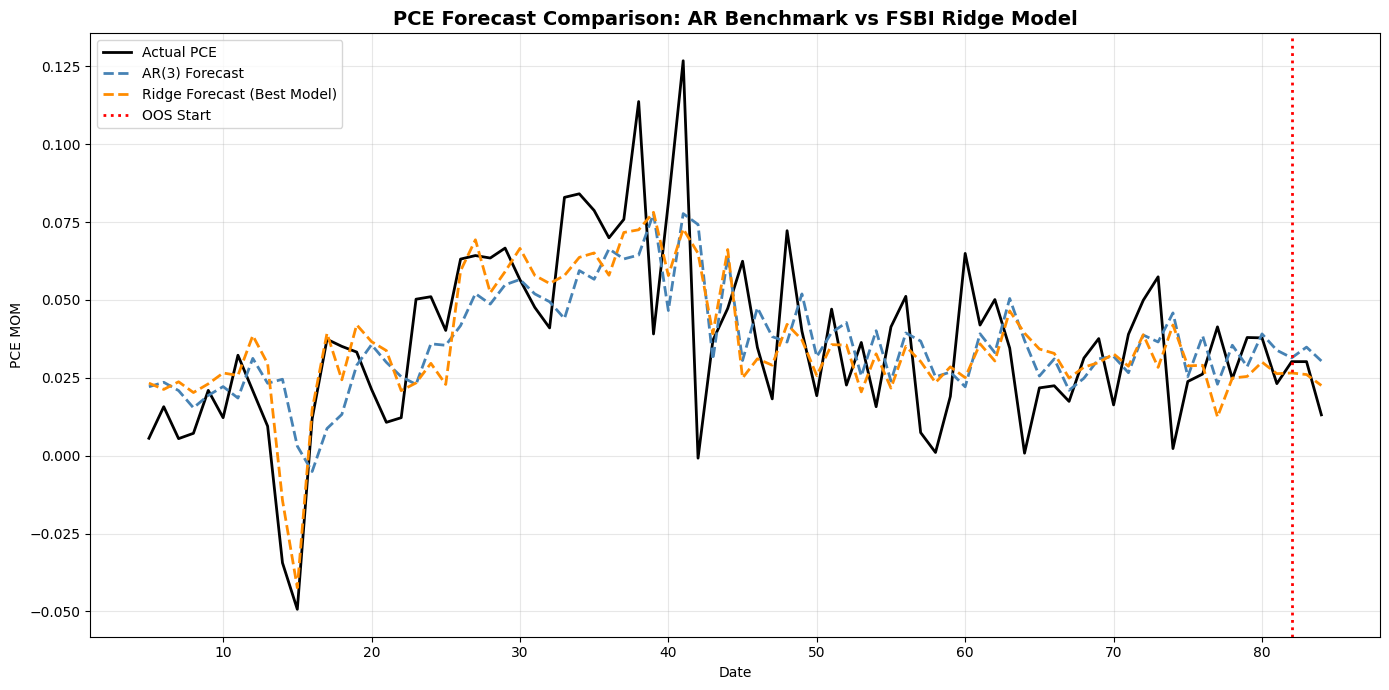

In [80]:
# =====================================================
# FINAL FORECAST PLOT: AR vs RIDGE vs ACTUAL
# =====================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Rebuild predictions on FULL SAMPLE
# -----------------------------

# AR(3) predictions
X_A_full = sm.add_constant(model_df[ar_vars])
ar_full_pred = model_A.predict(X_A_full)

# Ridge predictions
X_full = model_df[vars_used]
X_full_scaled = scaler.transform(X_full)
ridge_full_pred = ridge.predict(X_full_scaled)

# Actual values
actual = model_df[target]

# Dates (index)
dates = model_df.index

# OOS boundary
split_date = dates[-oos]

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(14,7))

# Actual
plt.plot(dates, actual,
         color="black", linewidth=2, label="Actual PCE")

# AR forecast
plt.plot(dates, ar_full_pred,
         linestyle="--", color="steelblue",
         linewidth=2, label="AR(3) Forecast")

# Ridge forecast
plt.plot(dates, ridge_full_pred,
         linestyle="--", color="darkorange",
         linewidth=2, label="Ridge Forecast (Best Model)")

# OOS divider
plt.axvline(split_date,
            color="red", linestyle=":",
            linewidth=2, label="OOS Start")

# Styling
plt.title("PCE Forecast Comparison: AR Benchmark vs FSBI Ridge Model",
          fontsize=14, fontweight="bold")

plt.ylabel("PCE MOM")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

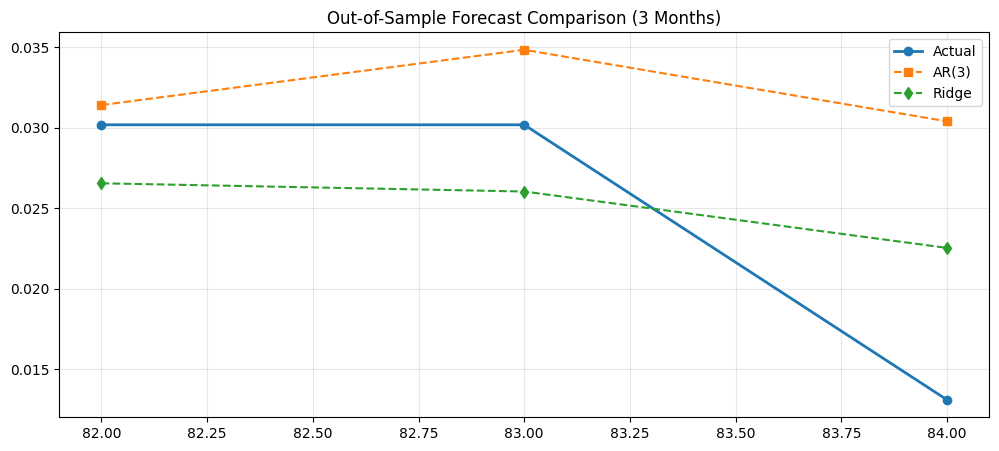

In [81]:
plt.figure(figsize=(12,5))

plt.plot(dates[-oos:], actual[-oos:], 'o-', label="Actual", linewidth=2)
plt.plot(dates[-oos:], ar_full_pred[-oos:], 's--', label="AR(3)")
plt.plot(dates[-oos:], ridge_full_pred[-oos:], 'd--', label="Ridge")

plt.title("Out-of-Sample Forecast Comparison (3 Months)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [82]:
# =====================================================
# FACTOR-AUGMENTED FORECAST (FAF)
# FSBI → Forecast Macro State → Forecast PCE
# =====================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import numpy as np
import pandas as pd

# -----------------------------
# SETTINGS
# -----------------------------
target = "PCE_MOM"
oos = 3

# macro variables that won earlier
macro_vars = [
    "Unemployment_normalized_lag1",
    "CrudeOilPrices_normalized_lag1",
    "CreditSpreadBAA_normalized_lag1",
    "CreditSpreadGS10_normalized_lag1"
]

# -----------------------------
# STEP 1: BUILD MACRO FACTOR
# -----------------------------
macro_df = data[macro_vars].dropna()

scaler_macro = StandardScaler()
macro_scaled = scaler_macro.fit_transform(macro_df)

pca = PCA(n_components=1)
macro_factor = pca.fit_transform(macro_scaled)

data.loc[macro_df.index, "MacroFactor"] = macro_factor.flatten()

# -----------------------------
# STEP 2: FORECAST FACTOR USING FSBI
# -----------------------------
factor_vars = [
    "MacroFactor",
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized"
]

factor_df = data[factor_vars].dropna().copy()

# lag factor
factor_df["MacroFactor_lag1"] = factor_df["MacroFactor"].shift(1)
factor_df = factor_df.dropna()

train_f = factor_df.iloc[:-oos]
test_f  = factor_df.iloc[-oos:]

Xf_train = sm.add_constant(
    train_f[["MacroFactor_lag1",
             "Real Sales MOM % - SA_normalized",
             "Transaction MOM % - SA_normalized"]]
)

Xf_test = sm.add_constant(
    test_f[["MacroFactor_lag1",
            "Real Sales MOM % - SA_normalized",
            "Transaction MOM % - SA_normalized"]]
)

yf_train = train_f["MacroFactor"]

factor_model = sm.OLS(yf_train, Xf_train).fit()

factor_pred = factor_model.predict(Xf_test)

# store predicted factor
factor_df.loc[test_f.index, "MacroFactor_forecast"] = factor_pred

# use actual in-sample, forecast OOS
factor_df["MacroFactor_used"] = factor_df["MacroFactor"]
factor_df.loc[test_f.index, "MacroFactor_used"] = factor_df.loc[test_f.index, "MacroFactor_forecast"]

# -----------------------------
# STEP 3: FORECAST PCE USING FACTOR
# -----------------------------
pce_vars = [
    "PCE_MOM_lag1",
    "PCE_MOM_lag2",
    "PCE_MOM_lag3",
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized",
    "MacroFactor_used"
]

model_df = data.join(factor_df["MacroFactor_used"])[pce_vars + [target]].dropna()

train_df = model_df.iloc[:-oos]
test_df  = model_df.iloc[-oos:]

X_train = train_df[pce_vars]
X_test  = test_df[pce_vars]
y_train = train_df[target]
y_test  = test_df[target]

# Ridge (same winner model type)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

ridge_faf = Ridge(alpha=1.0)
ridge_faf.fit(X_train_s, y_train)

y_pred_faf = ridge_faf.predict(X_test_s)

rmse_faf = np.sqrt(mean_squared_error(y_test, y_pred_faf))

da_faf   = directional_accuracy(y_test, y_pred_faf)
mape_faf = mape(y_test, y_pred_faf)

print("\n🌐 FACTOR-AUGMENTED MODEL RMSE:", rmse_faf)
print("*** Factor-Augmented Directional Accuracy: {:.1f}%".format(da_faf))
print("*** Factor-Augmented MAPE                : {:.2f}%".format(mape_faf))


🌐 FACTOR-AUGMENTED MODEL RMSE: 0.007790662073759839
*** Factor-Augmented Directional Accuracy: 100.0%
*** Factor-Augmented MAPE                : 36.97%
